This file is part of GaPSE
Copyright (C) 2022 Matteo Foglieni

GaPSE is free software: you can redistribute it and/or modify
it under the terms of the GNU General Public License as published by
the Free Software Foundation, either version 3 of the License, or
(at your option) any later version.

GaPSE is distributed in the hope that it will be useful, but
WITHOUT ANY WARRANTY; without even the implied warranty of
MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the GNU
General Public License for more details.

You should have received a copy of the GNU General Public License
along with GaPSE. If not, see <http://www.gnu.org/licenses/>.

# Iln_terms

Here we plot all the $I_\ell^n$ integrals that GaPSE uses to build every Two-Point
Correlation Function (TPCF), together with their asymptotic behaviour for
$s \rightarrow 0$.

All the plots and the data are saved in the `Iln_terms/` directory.

The formulas and the limits are only *stated* here; their derivation, with proof, is in
the [The $I_\ell^n$ integrals](../docs/src/IlnIntegrals.md) page of the manual.

## The theory in a nutshell

Every $\xi$ that GaPSE computes is a sum of terms of the form
$J(\chi, s, y) \, I_\ell^n(\Delta\chi)$, where

$$
    I_\ell^n(s) := \int_0^{+\infty} \frac{\mathrm{d}q}{2\pi^2} \, q^2 \, P(q) \,
        \frac{j_\ell(q s)}{(q s)^n}
$$

with $P(q)$ the input matter Power Spectrum at $z=0$ and $j_\ell$ the spherical Bessel
function of order $\ell$. GaPSE needs eight of them, $I_0^0$, $I_2^0$, $I_4^0$, $I_0^2$,
$I_2^2$, $I_3^1$, $I_1^3$ and $I_1^1$, plus the regularized

$$
    \tilde{I}_0^4(s) := \int_0^{+\infty} \frac{\mathrm{d}q}{2\pi^2} \, q^2 \, P(q) \,
        \frac{j_0(q s) - 1}{(q s)^4} \; ,
$$

whose subtraction removes the otherwise divergent $s^{-4}$ piece.

It is convenient to introduce the moments of the Power Spectrum

$$
    \sigma_i = \int_{k_\mathrm{min}}^{k_\mathrm{max}} \frac{\mathrm{d}q}{2 \pi^2} \,
        q^{2-i} \, P(q) \; ,
$$

which are the only property of $P(q)$ the limits depend on. Using the series expansion of
the spherical Bessel function near the origin,
$j_\ell(x) = x^\ell / (2\ell+1)!! + \mathcal{O}(x^{\ell+2})$, one gets

$$
    I_\ell^n(s) \; \underset{s \rightarrow 0}{\sim} \;
        \frac{\sigma_{n-\ell}}{(2\ell+1)!!} \, s^{\,\ell-n}
    \qquad \qquad
    \tilde{I}_0^4(s) \; \underset{s \rightarrow 0}{\sim} \; -\frac{\sigma_2}{6 \, s^2}
$$

so that the sign of $\ell - n$ decides everything:

| | $\ell$ | $n$ | $s \rightarrow 0$ | limit |
|:---|:---:|:---:|:---|:---|
| $I_0^0$ | 0 | 0 | $\sigma_0$ | const |
| $I_2^0$ | 2 | 0 | $\sigma_{-2} \, s^2 / 15$ | $0$ |
| $I_4^0$ | 4 | 0 | $\sigma_{-4} \, s^4 / 945$ | $0$ |
| $I_0^2$ | 0 | 2 | $\sigma_2 \, s^{-2}$ | $+\infty$ |
| $I_2^2$ | 2 | 2 | $\sigma_0 / 15$ | const |
| $I_3^1$ | 3 | 1 | $\sigma_{-2} \, s^2 / 105$ | $0$ |
| $I_1^3$ | 1 | 3 | $\sigma_2 \, s^{-2} / 3$ | $+\infty$ |
| $I_1^1$ | 1 | 1 | $\sigma_0 / 3$ | const |
| $\tilde{I}_0^4$ | - | - | $-\sigma_2 \, s^{-2} / 6$ | $+\infty$ |

The diverging ones are never a problem in practice: inside a TPCF they always come
multiplied by a $J$ carrying the matching positive power of $\Delta\chi$.

In [1]:
using Pkg
Pkg.activate(@__DIR__)

# This environment is (re)built here, so that a fresh clone - or a different
# Julia version - needs no manual setup step.
#  - GaPSE is NOT a registered package: an environment reaches it only through
#    the `path` entry that `Pkg.develop` writes into `Manifest.toml`. Checking
#    `Base.identify_package` alone is not enough: it resolves the UUID from
#    `Project.toml` and succeeds even when the source cannot be found.
#  - `Project.toml` holds names and UUIDs only, is Julia-version INdependent and
#    is tracked by git; it is rebuilt from `THEORY_DEPS` if it is missing.
#  - `Manifest.toml` holds the resolved versions, IS Julia-version specific and
#    is gitignored; `Pkg.resolve()` + `Pkg.instantiate()` rebuild it for the
#    Julia that is running. `resolve` first, or `instantiate` refuses whenever
#    `Project.toml` declares more than the manifest knows about.
# Nothing is downloaded when the environment is already complete.
let THEORY_DEPS = ["Plots", "PyPlot", "LaTeXStrings", "QuadGK",
                   "DelimitedFiles", "Printf", "SpecialFunctions"]
    declared = collect(keys(Pkg.project().dependencies))
    id = Base.identify_package("GaPSE")
    if !("GaPSE" in declared) || isnothing(id) || isnothing(Base.locate_package(id))
        @info "theory/: making the GaPSE of this repository available"
        Pkg.develop(path=dirname(@__DIR__))
    end
    todo = filter(d -> !(d in declared), THEORY_DEPS)
    isempty(todo) || (@info "theory/: adding the missing dependencies" todo; Pkg.add(todo))
    Pkg.resolve()
    Pkg.instantiate()
end

using GaPSE

using Plots, LaTeXStrings, QuadGK, DelimitedFiles, Printf
using SpecialFunctions: sphericalbesselj, gamma

# `pyplot()` needs a working matplotlib; `gr()` is used instead where it is absent
try
    pyplot()
catch err
    @warn "theory/: PyPlot cannot be initialised; falling back to the GR backend. " *
          "The figures will look slightly different." exception = err
    gr()
end


  Activating project at `~/AAA_TESI_MAGISTRALE/GaPSE_CODING/GaPSE-worktree/myspline/theory`
     Project No packages added to or removed from `~/AAA_TESI_MAGISTRALE/GaPSE_CODING/GaPSE-worktree/myspline/theory/Project.toml`
    Manifest No packages added to or removed from `~/AAA_TESI_MAGISTRALE/GaPSE_CODING/GaPSE-worktree/myspline/theory/Manifest.toml`


Plots.PyPlotBackend()

In [2]:
const PATH_TO_GAPSE = normpath(joinpath(@__DIR__, ".."))

# Input matter Power Spectrum P(q) at z=0
const FILE_PS = joinpath(PATH_TO_GAPSE, "data", "WideA_ZA_pk.dat")

# Directory where the plots and the data will be saved
const DIR = joinpath(@__DIR__, "Iln_terms")
@assert isdir(DIR) "ERROR: DIR=$DIR DOESN'T EXIST!!!"

# Set this to `true` in order to save a copy of the plots where the
# documentation expects to find them.
const SAVE_TO_DOCS = true
const DOCS_ASSETS = joinpath(PATH_TO_GAPSE, "docs", "src", "assets", "Iln_terms")

# CAREFUL: these are NOT the integration extremes of the I_l^n!
# They are only the ones used by `IPSTools` for its own sigma_0, ..., sigma_4.
const K_MIN, K_MAX = 1e-6, 10.0

# THESE are the integration extremes of the I_l^n: `IPSTools` hard-codes
# `kmin, kmax, s0 = 1e-5, 1e3, 1e-3` (see `src/IPSTools.jl`) and hands them over to
# `xicalc`, no matter what `k_min` and `k_max` you pass to it.
# The sigma_i that appear in the asymptotic limits of the I_l^n must be computed with
# THESE extremes, otherwise the comparison is meaningless: sigma_2 barely notices the
# difference, but sigma_{-2} and sigma_{-4} change by 5 and 8 orders of magnitude.
const XICALC_KMIN, XICALC_KMAX = 1e-5, 1e3

# Comoving separations where the I_l^n will be evaluated
const SS = 10 .^ range(-6, 5, length=800)

# Comoving separations where the I_l^n will also be computed by direct quadrature.
# We stop at 1e-2 because there q*s <= 10 over the whole integration range, so the
# integrand is still perfectly resolved by `QUAD_GRID` below.
const SS_DIRECT = 10 .^ range(-6, -2, length=50)

# log-spaced grid used by `I_direct`
const QUAD_GRID = 10 .^ range(log10(XICALC_KMIN), log10(XICALC_KMAX), length=50_000)

50000-element Vector{Float64}:
    1.0e-5
    1.0003684888586454e-5
    1.0007371135013277e-5
    1.0011058739780858e-5
    1.0014747703389691e-5
    1.0018438026340534e-5
    1.0022129709134248e-5
    1.0025822752271963e-5
    1.0029517156254928e-5
    1.003321292158458e-5
    1.00369100487626e-5
    1.0040608538290775e-5
    1.0044308390671155e-5
    ⋮
  995.9555700099331
  996.3225685411866
  996.6897023073109
  997.0569713581367
  997.4243757435158
  997.7919155133176
  998.1595907174296
  998.5274014057579
  998.895347628228
  999.2634294347807
  999.6316468753781
 1000.0

## Three things to keep in mind

Everything above is exact, but it is **not** what you see if you naively plot an
`IntegralIPS` down to $s = 10^{-4}$.

**1.** An `IntegralIPS` is a spline only between its `left` and `right` fields. Below
`left` $=$ `fit_min` $= 0.05 \, h_0^{-1}\mathrm{Mpc}$ it returns a power law
$a + b \, s^{s_\mathrm{L}}$, fitted on $[0.05, 0.5]$ and seeded with a negative exponent:
every $I_\ell^n$ therefore *appears* to diverge as $s \rightarrow 0$, whatever its true
behaviour. This is not a bug — GaPSE never evaluates them there — but that whole region
of the plot carries no information about the limits. We shade it in grey.

**2.** `IPSTools` hard-codes $k_\mathrm{min}, k_\mathrm{max} = 10^{-5}, 10^{3}$ for the
`xicalc` call that builds the $I_\ell^n$, regardless of its `k_min`/`k_max` keywords,
which only affect the $\sigma_i$ it stores. The $\sigma_i$ of the asymptotes must use the
*former* extremes: $\sigma_2$ barely notices the difference (0.1%), but $\sigma_{-2}$
changes by a factor $5 \times 10^4$ and $\sigma_{-4}$ by $5 \times 10^8$, since those
integrals are completely dominated by their upper extreme.

**3.** Truncating the $j_\ell$ series needs $(qs)^2 \ll 1$ for every $q$ that carries
weight, i.e. $s \ll 1/k_\mathrm{max} = 10^{-3} \, h_0^{-1}\mathrm{Mpc}$ — which is 50
times *smaller* than `fit_min`. The window where the limits hold and the window where the
spline is valid do not overlap, so the limits simply cannot be seen through `IPSTools`.
To check them we compute the integrals directly, with `I_direct` below.

In [3]:
ips = GaPSE.InputPS(FILE_PS)
tools = GaPSE.IPSTools(ips; k_min=K_MIN, k_max=K_MAX, N=1024,
    fit_min=0.05, fit_max=0.5, con=true)

# P(q) evaluated once and for all on `QUAD_GRID`, so that `I_direct` is cheap
const PQ_GRID = [ips(q) for q in QUAD_GRID]

# The small-q power law of the MATTER Power Spectrum, P(q) = PS_AMP * q^N_P, as `InputPS`
# fits it on [1e-6, 3e-6] (with `con=false`, so that its `l_a` is exactly zero).
# It is the only property of P(q) the large-s behaviour depends on.
#
# CAREFUL: N_P is the small-k slope of the matter P(k), NOT the exponent `n_s - 1` of the
# dimensionless primordial curvature spectrum. The two are related by
# P_m(k) ~ k^4 T^2(k) P_R(k) ~ k^n_s T^2(k), with T -> 1 on large scales, so N_P = n_s.
# We measure it rather than assume it: for `WideA_ZA_pk.dat` it comes out +0.9600 .
const N_P, PS_AMP = ips.l_si, ips.l_b

(0.9599997973713535, 3.0123088245442463e6)

`IPSTools` stores only $\sigma_0, ..., \sigma_4$, while the asymptotes of $I_2^0$,
$I_4^0$ and $I_3^1$ need the negative-index ones, so we recompute them here — over the
extremes of point 2 above.

In [4]:
const SIGMA_CACHE = Dict{Int,Float64}()

"""
    sigma(i; kmin=XICALC_KMIN, kmax=XICALC_KMAX) ::Float64

Return the moment of the input Power Spectrum

```math
\\sigma_i = \\int_{k_\\mathrm{min}}^{k_\\mathrm{max}}
    \\frac{\\mathrm{d}q}{2 \\pi^2} \\, q^{2-i} \\, P(q) \\; .
```

`IPSTools` stores only ``\\sigma_0, ..., \\sigma_4``, while the asymptotic limits of
``I_2^0``, ``I_4^0`` and ``I_3^1`` need the negative-index ones, so we recompute them here.

The default extremes are the ones `IPSTools` uses for the ``I_\\ell^n`` themselves, and
NOT the `k_min`/`k_max` it uses for its own ``\\sigma_i``: with `WideA_ZA_pk.dat` the
difference is negligible for ``\\sigma_2`` (0.1%) but it is a factor ``5 \\times 10^4``
for ``\\sigma_{-2}`` and ``5 \\times 10^8`` for ``\\sigma_{-4}``, because those integrals
are completely dominated by their upper extreme.
"""
sigma(i; kmin=XICALC_KMIN, kmax=XICALC_KMAX) =
    get!(SIGMA_CACHE, i) do
        quadgk(q -> ips(q) * q^(2 - i) / (2 * π^2), kmin, 1e-1, 1e1, kmax)[1]
    end

"""
    dfact(n) ::Int

Return the double factorial ``n!!`` (with ``n!! = 1`` for ``n \\leq 0``).
"""
dfact(n) = n <= 0 ? 1 : prod(n:-2:1)

# name, l, n, the IntegralIPS stored in `tools`
const ILN = [
    ("I00", 0, 0, tools.I00),
    ("I20", 2, 0, tools.I20),
    ("I40", 4, 0, tools.I40),
    ("I02", 0, 2, tools.I02),
    ("I22", 2, 2, tools.I22),
    ("I31", 3, 1, tools.I31),
    ("I13", 1, 3, tools.I13),
    ("I11", 1, 1, tools.I11),
]

8-element Vector{Tuple{String, Int64, Int64, GaPSE.IntegralIPS}}:
 ("I00", 0, 0, GaPSE.IntegralIPS(-0.38236715886962763, 13.434860103560382, -8.687579165898036, 0.05, GaPSE.MySpline([0.04958068241684655, 0.0504806571666747, 0.05139696800771511, 0.05232991146814945, 0.053279789458656385, 0.05424690937011323, 0.055231584173070954, 0.05623413251903487, 0.05725487884358375, 0.058294153471360736  …  82046.96109024975, 83536.25469578238, 85052.58154439961, 86596.43233600643, 88168.3066775569, 89768.71324473115, 91398.169946549, 93057.20409296977, 94746.35256553731, 96466.16199111959], [(33.6470629853983, -320.48105873947424, 0.0, 2.0224290998251666e6), (33.3601123514598, -315.56683178311533, 5460.405369480967, -621602.2557562329), (33.07506150365748, -307.1257139314805, 3751.6627121871425, 85529.25849130058), (32.791865413985796, -299.90220577913135, 3991.0445993429144, -99321.13532480963), (32.510510779373114, -292.58903783607224, 3708.0157180313217, -33422.825497280755), (32.23098004649093

In [5]:
@printf("                     [%.0e, %.0e]        [%.0e, %.0e] \n",
    XICALC_KMIN, XICALC_KMAX, K_MIN, K_MAX)
for i in [-4, -2, 0, 2]
    @printf("sigma_%-3d = %14.6e \t %14.6e \n", i, sigma(i),
        quadgk(q -> ips(q) * q^(2 - i) / (2 * π^2), K_MIN, K_MAX)[1])
end

                     [1e-05, 1e+03]        [1e-06, 1e+01] 
sigma_-4  =   1.269971e+13 	   2.406849e+04 
sigma_-2  =   2.346735e+07 	   4.377669e+02 
sigma_0   =   1.432850e+02 	   1.858428e+01 
sigma_2   =   1.011282e+02 	   1.010636e+02 


The direct quadrature. It is slow and usable only for $s \lesssim 10^{-2}$, where
the integrand still has no oscillation, but it is the only way to see the true
$s \rightarrow 0$ behaviour.

In [6]:
"""
    I_direct(l, n, s) ::Float64

Compute

```math
I_\\ell^n(s) = \\int_{k_\\mathrm{min}}^{k_\\mathrm{max}} \\frac{\\mathrm{d}q}{2\\pi^2}
    \\, q^2 \\, P(q) \\, \\frac{j_\\ell(qs)}{(qs)^n}
```

by brute-force trapezoidal quadrature on the log-spaced `QUAD_GRID`, with the same
extremes `xicalc` is given inside `IPSTools`.

This is slow and it is only usable for ``s \\lesssim 10^{-2}``, where the integrand still
has no oscillation, but it is the only way to see the true ``s \\rightarrow 0`` behaviour:
an `IntegralIPS` cannot show it, because below its `left` field it does not evaluate the
integral at all (see `plot_single`).
"""
function I_direct(l, n, s)
    integrand = [PQ_GRID[i] * QUAD_GRID[i]^3 * sphericalbesselj(l, QUAD_GRID[i] * s) /
                 (QUAD_GRID[i] * s)^n / (2 * π^2) for i in eachindex(QUAD_GRID)]
    lqs = log.(QUAD_GRID)
    return sum((integrand[i] + integrand[i+1]) * (lqs[i+1] - lqs[i]) / 2
               for i in 1:length(QUAD_GRID)-1)
end

"""
    I04_tilde_direct(s) ::Float64

Compute, by the same brute-force quadrature of `I_direct`,

```math
\\tilde{I}_0^4(s) = \\int_{k_\\mathrm{min}}^{k_\\mathrm{max}} \\frac{\\mathrm{d}q}{2\\pi^2}
    \\, q^2 \\, P(q) \\, \\frac{j_0(qs) - 1}{(qs)^4} \\; ,
```

i.e. the very same integral of `GaPSE.func_I04_tilde`.

Note that we CANNOT obtain it as `I_direct(0, 4, s) - sigma(4) / s^4`: the two terms are
equal up to ``\\mathcal{O}(s^2)``, so for small ``s`` the subtraction cancels every
significant digit. For the same reason the ratio ``(j_0(x)-1)/x^4`` is evaluated through
its series for ``x < 10^{-2}``, since `j_0(x) - 1` is pure round-off there.
"""
function I04_tilde_direct(s)
    # (j_0(x) - 1) / x^4 = -1/(6 x^2) + 1/120 - x^2/5040 + O(x^4)
    ratio(x) = x < 1e-2 ? -1 / (6 * x^2) + 1 / 120 - x^2 / 5040 :
               (sphericalbesselj(0, x) - 1) / x^4

    integrand = [PQ_GRID[i] * QUAD_GRID[i]^3 * ratio(QUAD_GRID[i] * s) / (2 * π^2)
                 for i in eachindex(QUAD_GRID)]
    lqs = log.(QUAD_GRID)
    return sum((integrand[i] + integrand[i+1]) * (lqs[i+1] - lqs[i]) / 2
               for i in 1:length(QUAD_GRID)-1)
end

I04_tilde_direct

In [7]:
"""
    asymptote(s, l, n) ::Float64

Return the leading small-``s`` behaviour of ``I_\\ell^n``:

```math
I_\\ell^n(s) \\; \\xrightarrow[s \\rightarrow 0]{} \\;
    \\frac{\\sigma_{n-\\ell}}{(2\\ell+1)!!} \\, s^{\\,\\ell-n} \\; .
```

It is reached only for ``s \\ll 1/k_\\mathrm{max} = 10^{-3}\\, h_0^{-1}\\mathrm{Mpc}``,
which is where every term of the ``j_\\ell`` series but the first becomes negligible.
"""
asymptote(s, l, n) = sigma(n - l) * s^(l - n) / dfact(2 * l + 1)

"""
    asymptote_tilde(s) ::Float64

Return the leading small-``s`` behaviour of ``\\tilde{I}_0^4``, i.e.
``-\\sigma_2 / (6 \\, s^2)``.
"""
asymptote_tilde(s) = -sigma(2) / (6 * s^2)

"""
    mellin(l, mu) ::Float64

Return the Mellin transform of the spherical Bessel function,

```math
\\int_0^{+\\infty} \\mathrm{d}x \\, x^{\\mu-1} \\, j_\\ell(x) =
    \\sqrt{\\frac{\\pi}{2}} \\; 2^{\\,\\mu-3/2} \\;
    \\frac{\\Gamma\\left(\\frac{\\ell+\\mu}{2}\\right)}
          {\\Gamma\\left(\\frac{\\ell-\\mu+3}{2}\\right)} \\; ,
```

which converges for ``-\\ell < \\mu < 2`` and is meant as its analytic continuation
outside that strip.
"""
mellin(l, mu) = √(π / 2) * 2.0^(mu - 3 / 2) * gamma((l + mu) / 2) / gamma((l - mu + 3) / 2)

"""
    asymptote_large(s, l, n) ::Float64

Return the leading large-``s`` behaviour of ``I_\\ell^n``:

```math
I_\\ell^n(s) \\; \\xrightarrow[s \\rightarrow +\\infty]{} \\;
    \\frac{A}{2\\pi^2} \\, \\mathcal{M}_\\ell(\\mu) \\, s^{-(3+n_P)} \\; ,
    \\qquad \\mu = 3 + n_P - n \\; ,
```

with ``P(q) \\rightarrow A \\, q^{n_P}`` for ``q \\rightarrow 0`` and
``\\mathcal{M}_\\ell`` the `mellin` transform above. ``n_P`` is the small-``k`` slope of the
MATTER Power Spectrum (``\\simeq +0.96``), not the ``n_s - 1`` of the dimensionless
primordial curvature one.

It is NOT obtained by replacing ``P`` with its small-``q`` power law inside the integral:
that interchange is illegitimate, and for ``\\mu \\geq 2`` it produces a divergent
integral. It follows from the residue at the rightmost pole of the Mellin-Parseval
representation; see the manual.

The exponent does not depend on ``\\ell`` nor on ``n``: the ``s^{-n}`` coming from the
``(qs)^{-n}`` factor exactly cancels the ``n`` carried by ``\\mu``.

It holds as long as the region ``q \\sim 1/s`` that dominates the integral still lies
inside the ``P \\propto q^{n_P}`` regime, i.e. for
``1 \\ll s \\ll 1/k_\\mathrm{min} = 10^5 \\, h_0^{-1}\\mathrm{Mpc}``.
"""
asymptote_large(s, l, n) = PS_AMP / (2 * π^2) * mellin(l, 3 + N_P - n) * s^(-(3 + N_P))

asymptote_large

## The plots

We plot $|I_\ell^n(s)|$ rather than $I_\ell^n(s)$: all these integrals oscillate and
change sign at large $s$, where a logarithmic vertical axis would not be defined. At small
$s$, the regime we care about here, they keep a constant sign, so the absolute value is
immaterial.

Each figure shows the `IntegralIPS` (solid), the direct quadrature (dotted), the analytic
asymptote (dashed, black) and, in grey, the two regions where the `IntegralIPS` is an
extrapolation rather than the integral.

In [8]:
"""
    logticks(lo, hi)

Return the decade ticks (major labelled, minor unlabelled) that fall inside `[lo, hi]`.

Generating them from the plotted range, instead of once and for all, is what keeps the
labels of the left edge from piling up on each other when a figure does not span all the
decades.
"""
function logticks(lo, hi)
    b_min, b_max = floor(Int, log10(lo)), ceil(Int, log10(hi))
    ts = [a * 10.0^b for b in b_min:b_max for a in 1:9]
    ls = [a == 1 ? L"10^{%$b}" : nothing for b in b_min:b_max for a in 1:9]
    keep = lo .<= ts .<= hi
    return (ts[keep], ls[keep])
end

# common keyword arguments, so that all the figures look the same
plot_kwargs(lo, hi) = Dict(
    :xaxis => :log, :yaxis => :log,
    :xlabel => L"s \quad [h_0^{-1}\mathrm{Mpc}]",
    :xticks => logticks(lo, hi),
    :xlims => (lo, hi),
    :legend => :bottomleft,
    :legendfontsize => 7,
    :size => (700, 470),
)

"""
    shade_extrapolations!(p, iln)

Grey out the two regions where the `iln::IntegralIPS` does NOT evaluate the integral.

An `IntegralIPS` is a spline only between its `left` (`= fit_min = 0.05` for all the
``I_\\ell^n``, `0.1` for ``\\tilde{I}_0^4``) and its `right` fields; outside them it
returns a power law ``a + b \\, s^{\\,s_i}`` whose coefficients are fitted on
``[\\mathrm{fit\\_min}, \\mathrm{fit\\_max}] = [0.05, 0.5]`` (left) and on the last 16
points of the `xicalc` grid (right).

That extrapolation has nothing to do with the true ``s \\rightarrow 0`` behaviour, and
this is the single reason why a naive plot of an `IntegralIPS` down to
``s = 10^{-4}`` looks nothing like the analytic asymptote.
"""
function shade_extrapolations!(p, iln)
    SS[begin] < iln.left &&
        vspan!(p, [SS[begin], iln.left]; color=:gray, alpha=0.13, label="")
    iln.right < SS[end] &&
        vspan!(p, [iln.right, SS[end]]; color=:gray, alpha=0.13, label="")
    vline!(p, [iln.left, iln.right]; color=:gray, ls=:dot, lw=1, label="")
    return p
end

"""
    plot_single(name, l, n, f; tilde=false)

Plot ``|I_\\ell^n(s)|`` in log-log scale and save the figure as `Iln_terms/<name>.png`.

Each figure carries four things:

 1. the `IntegralIPS` stored in `IPSTools` (solid), i.e. what GaPSE actually uses;
 2. the direct quadrature `I_direct` for ``s \\leq 10^{-2}`` (dotted), i.e. the true
    value of the integral there;
 3. the analytic small-``s`` asymptote (dashed, black);
 4. two grey bands, marking where the `IntegralIPS` is a power-law extrapolation and
    not the integral.

We plot the absolute value because all these integrals oscillate and change sign at
large ``s``, where a logarithmic vertical axis would not be defined.
"""
function plot_single(name, l, n, f; tilde=false)
    ys = [f(s) for s in SS]
    dir = tilde ? [I04_tilde_direct(s) for s in SS_DIRECT] :
          [I_direct(l, n, s) for s in SS_DIRECT]

    # The asymptotes are drawn only over the side of the plot they describe: they are pure
    # power laws, so over the whole 11 decades of `SS` they would span 25 of them and
    # squash everything else.
    ss_asy = SS[SS.<=1.0]
    asy = tilde ? [asymptote_tilde(s) for s in ss_asy] :
          [asymptote(s, l, n) for s in ss_asy]
    ss_big = SS[SS.>=10.0]
    big = tilde ? nothing : [asymptote_large(s, l, n) for s in ss_big]

    lab = tilde ? L"|\tilde{I}_0^4(s)| \;\; \mathrm{(IPSTools)}" :
          L"|I_{%$l}^{%$n}(s)| \;\; \mathrm{(IPSTools)}"
    asylab = tilde ? L"|-\sigma_2 / (6 s^2)|" :
             L"|\sigma_{%$(n-l)} \, s^{%$(l-n)} / %$(dfact(2 * l + 1))|"

    # the vertical range is set by the data alone, letting the asymptote clip
    vals = filter(v -> isfinite(v) && v > 0, abs.(vcat(ys, dir)))

    p = plot(; ylabel=tilde ? L"|\tilde{I}_0^4(s)|" : L"|I_{\ell}^{n}(s)|",
        title=tilde ? L"\tilde{I}_0^4" : L"I_{%$l}^{%$n}",
        ylims=(minimum(vals) / 30, maximum(vals) * 30),
        plot_kwargs(SS[begin], SS[end])...)
    plot!(p, ss_asy, abs.(asy); label=asylab, ls=:dash, lw=2, color=:black)
    tilde || plot!(p, ss_big, abs.(big);
        label=L"|A \, \mathcal{M}_{%$l}(\mu) \, s^{-(3+n_P)} / 2\pi^2|",
        ls=:dashdot, lw=2, color=:darkred)
    plot!(p, SS, abs.(ys); label=lab, lw=2)
    plot!(p, SS_DIRECT, abs.(dir); label=L"\mathrm{direct \; quadrature}", lw=4, ls=:dot)
    shade_extrapolations!(p, f)

    savefig(p, joinpath(DIR, name * ".png"))
    SAVE_TO_DOCS && savefig(p, joinpath(DOCS_ASSETS, name * ".png"))
    return p
end

plot_single

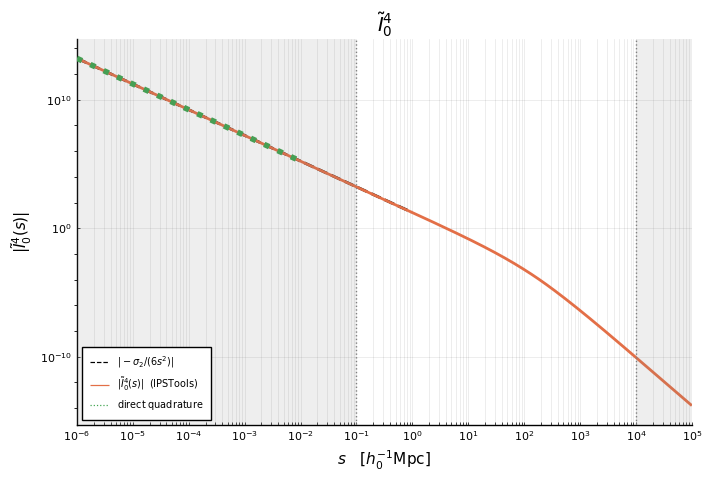

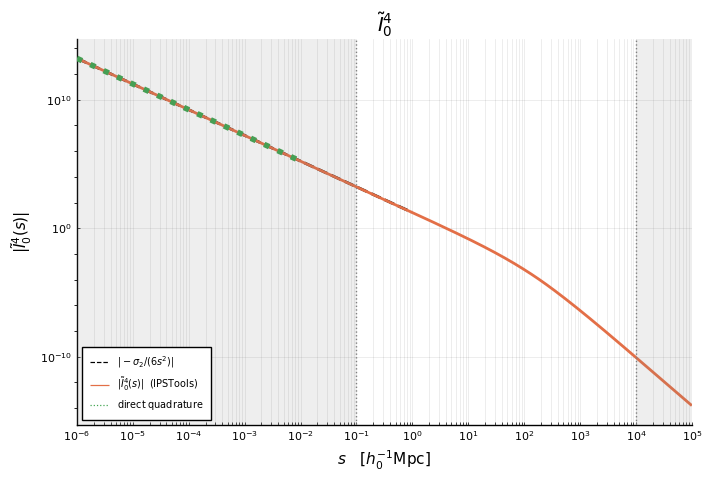

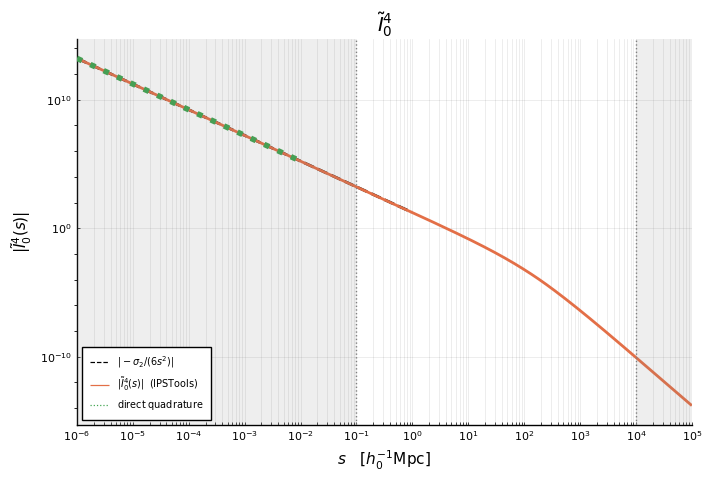

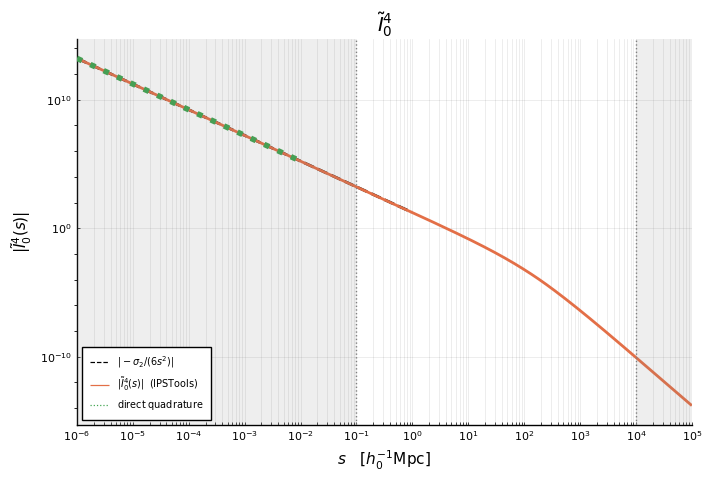

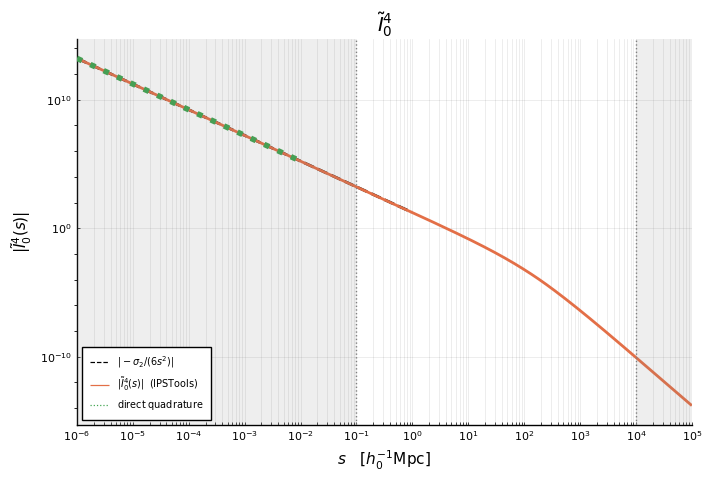

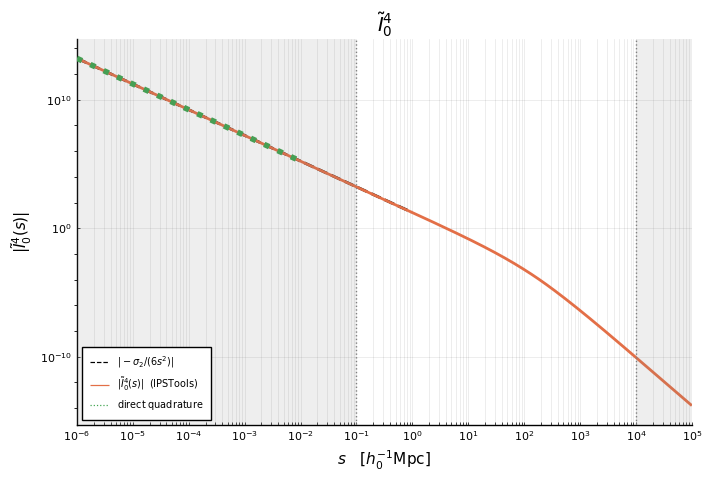

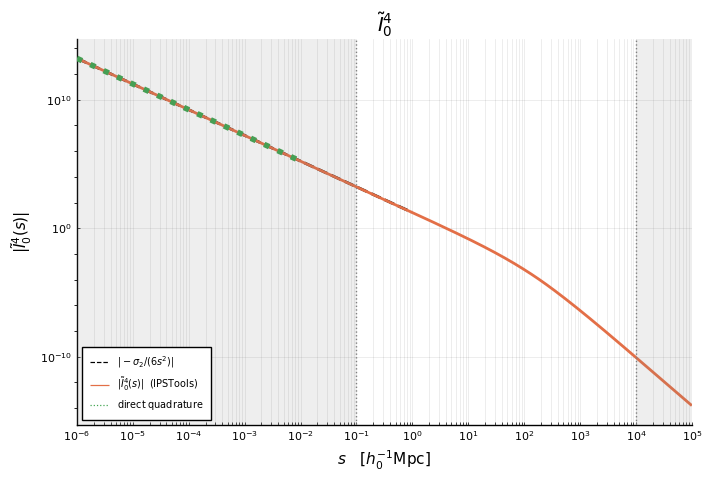

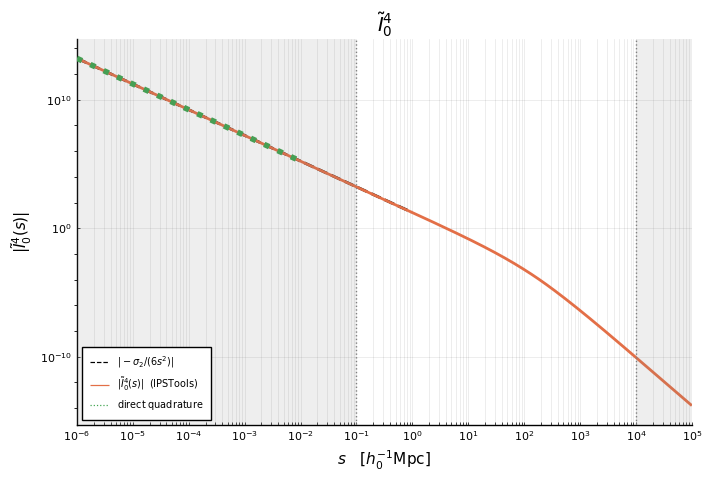

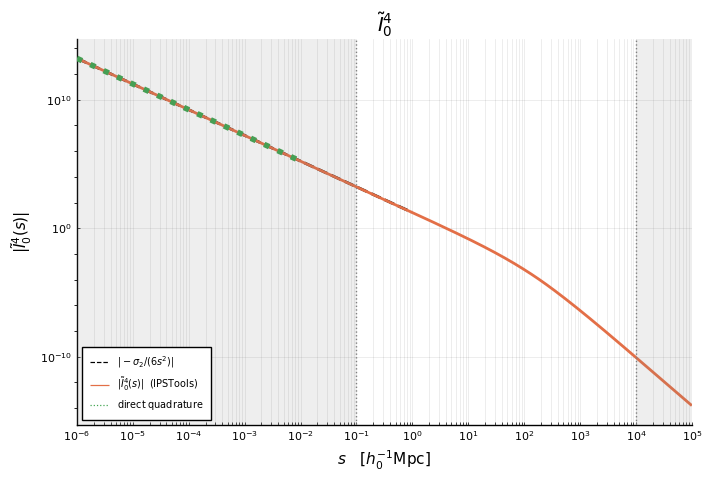

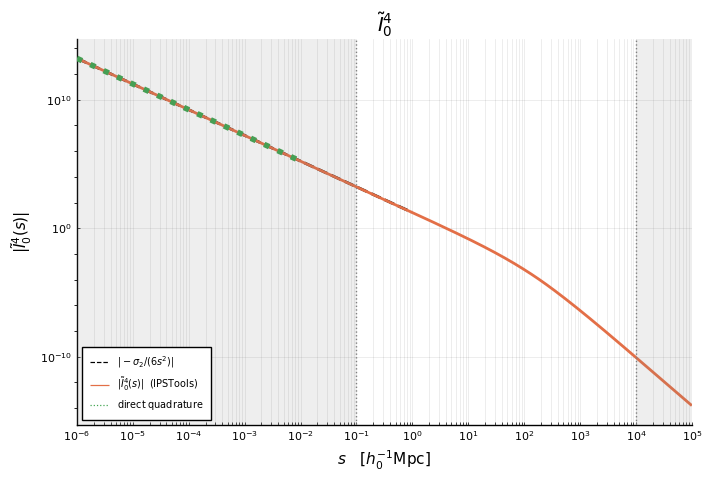

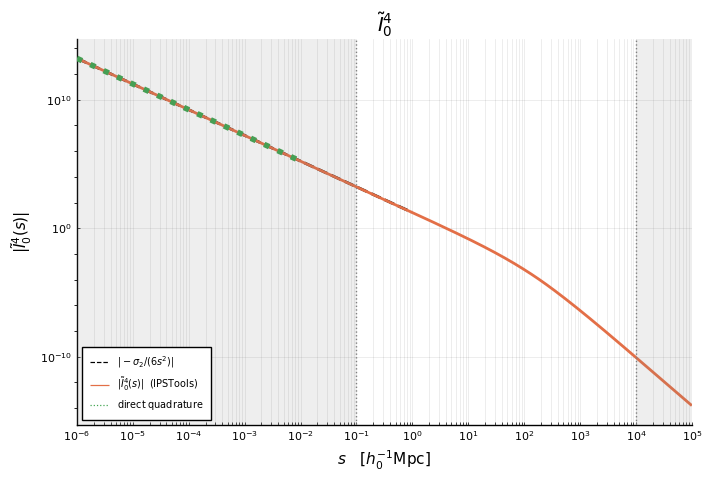

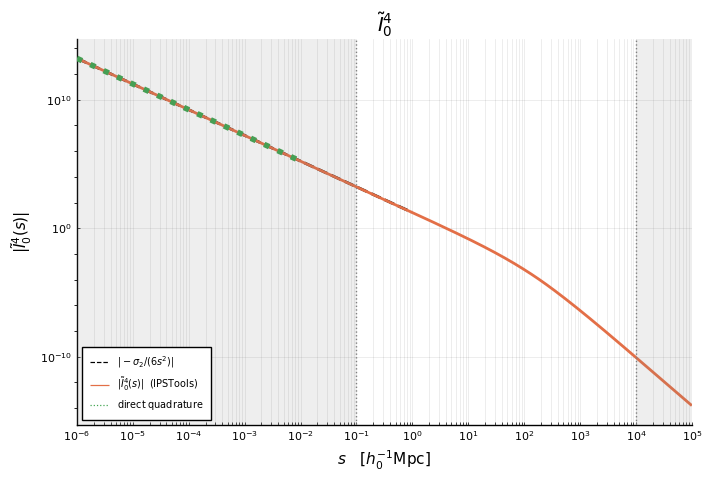

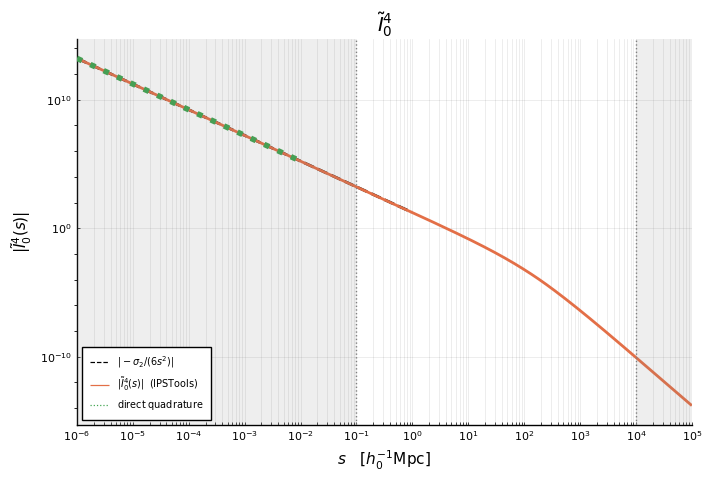

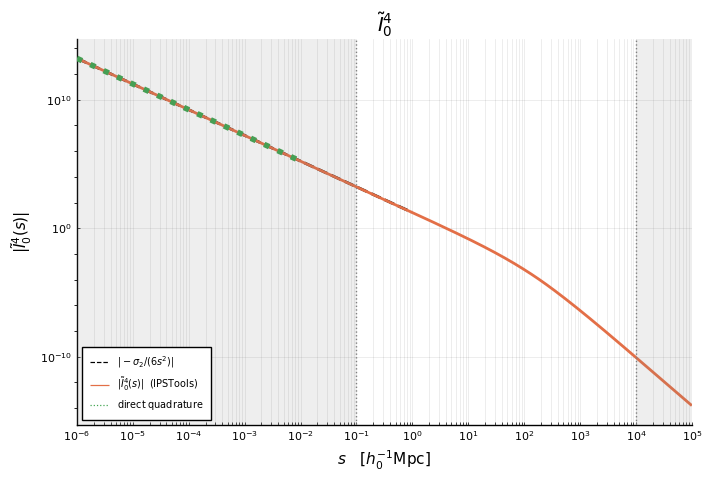

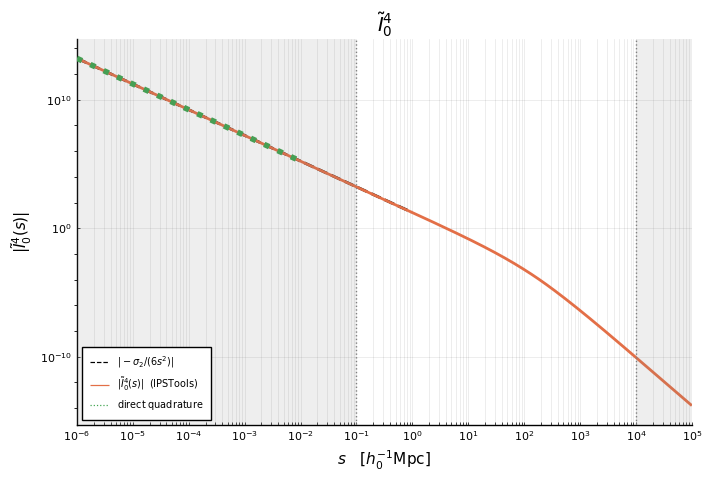

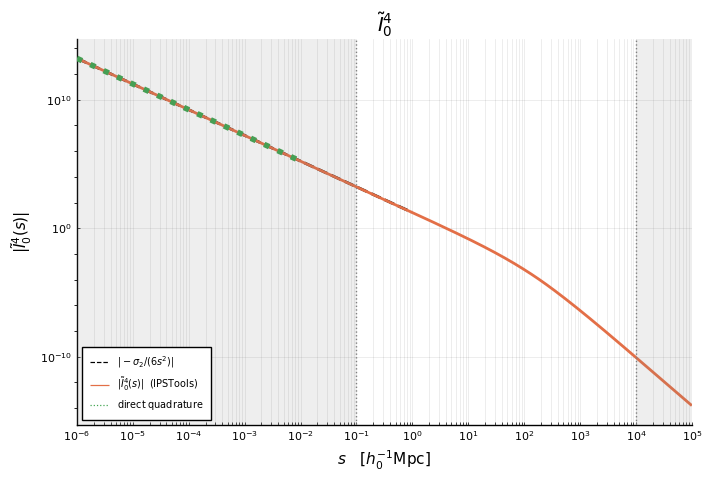

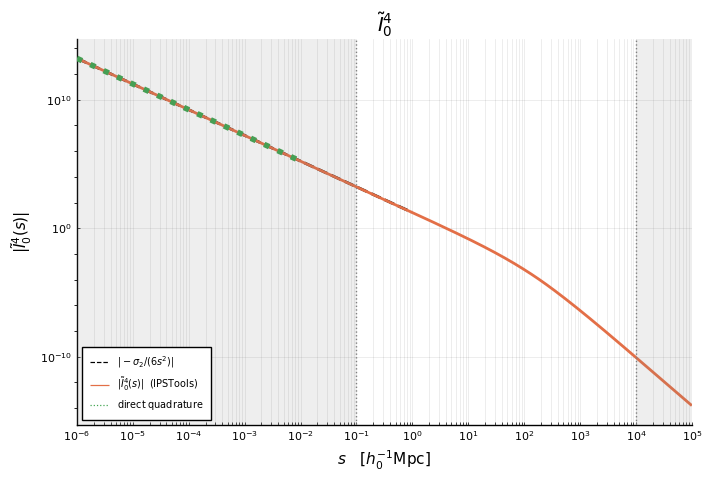

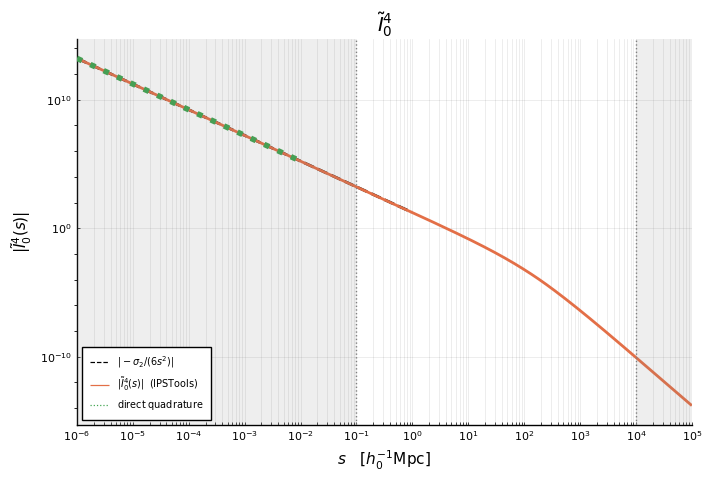

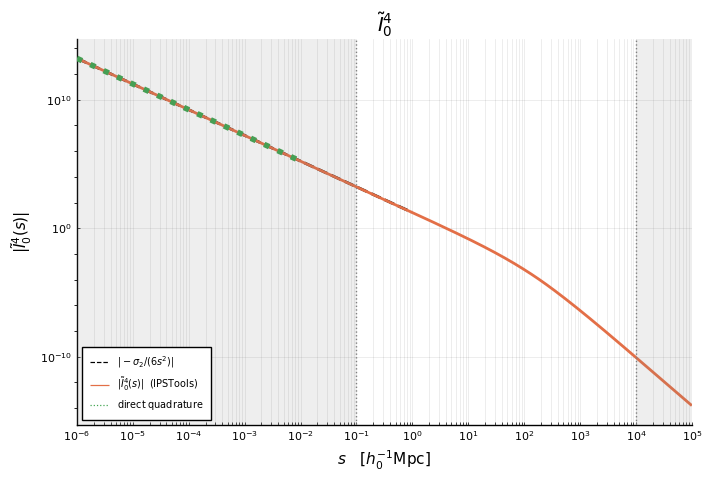

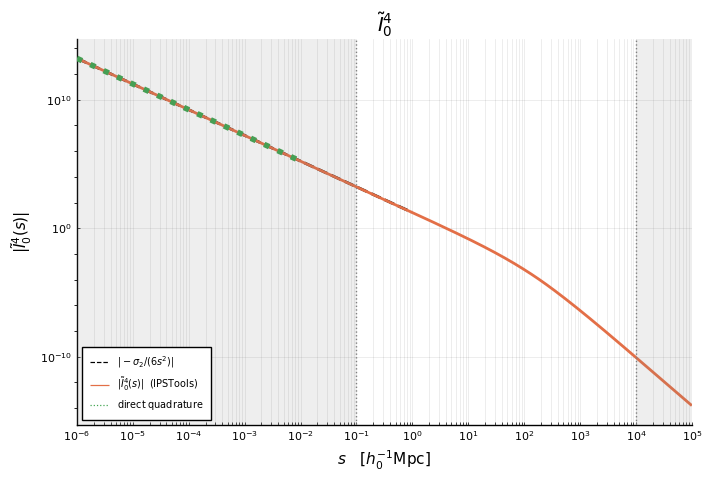

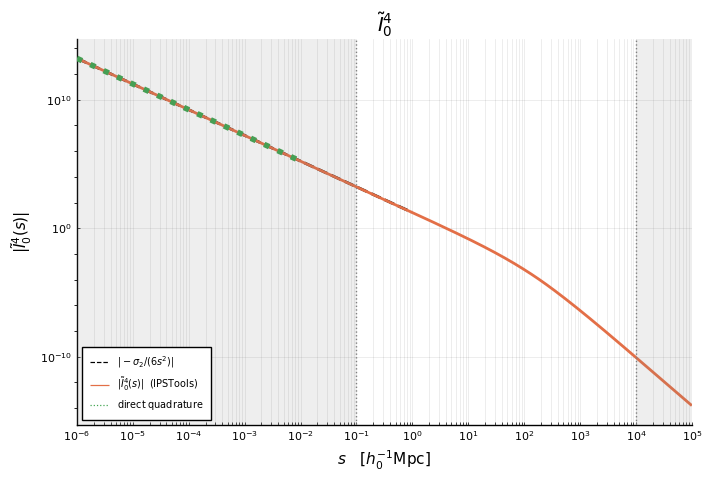

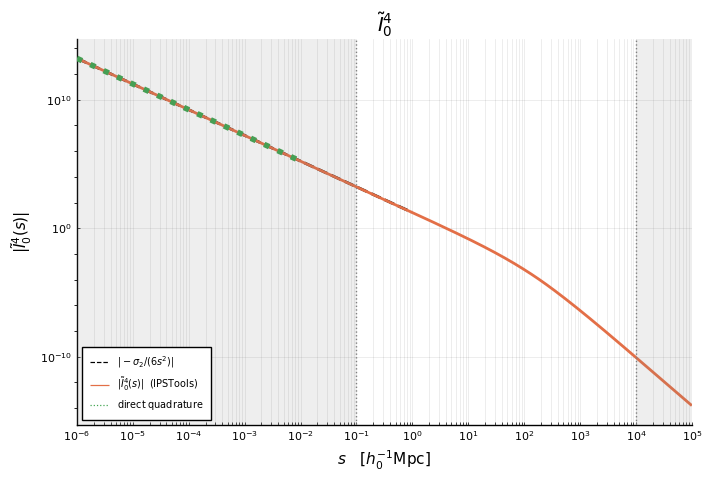

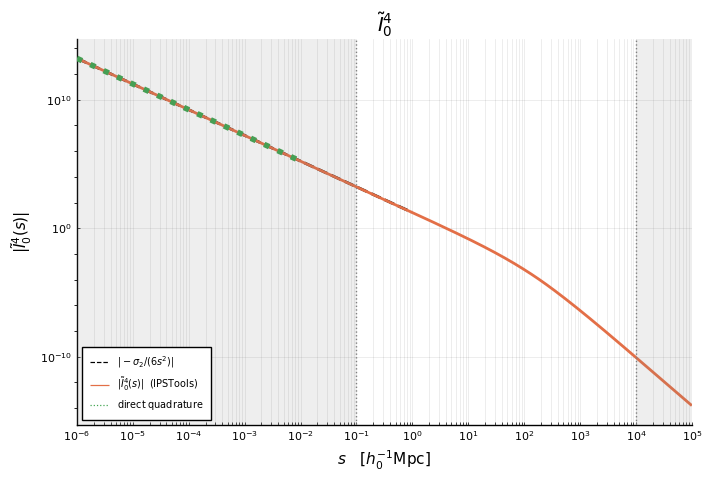

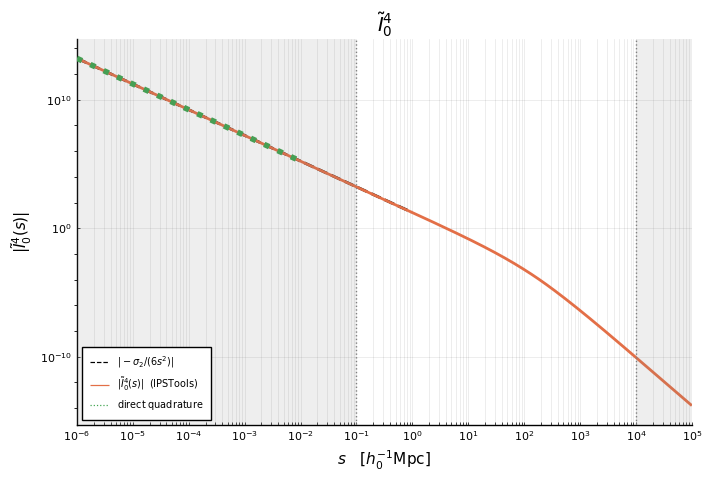

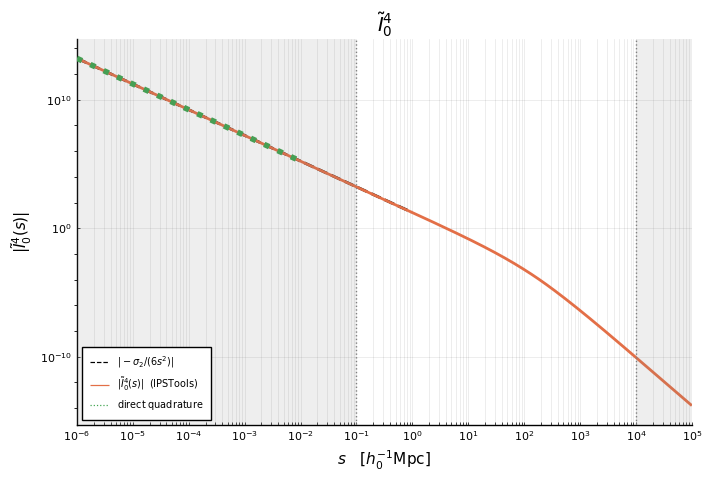

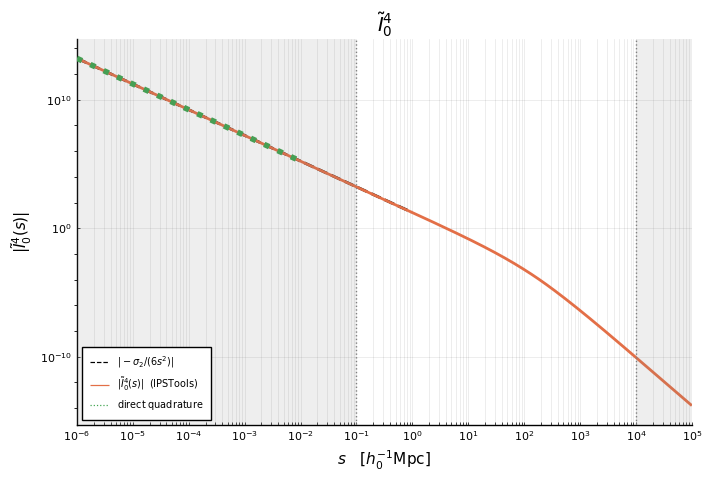

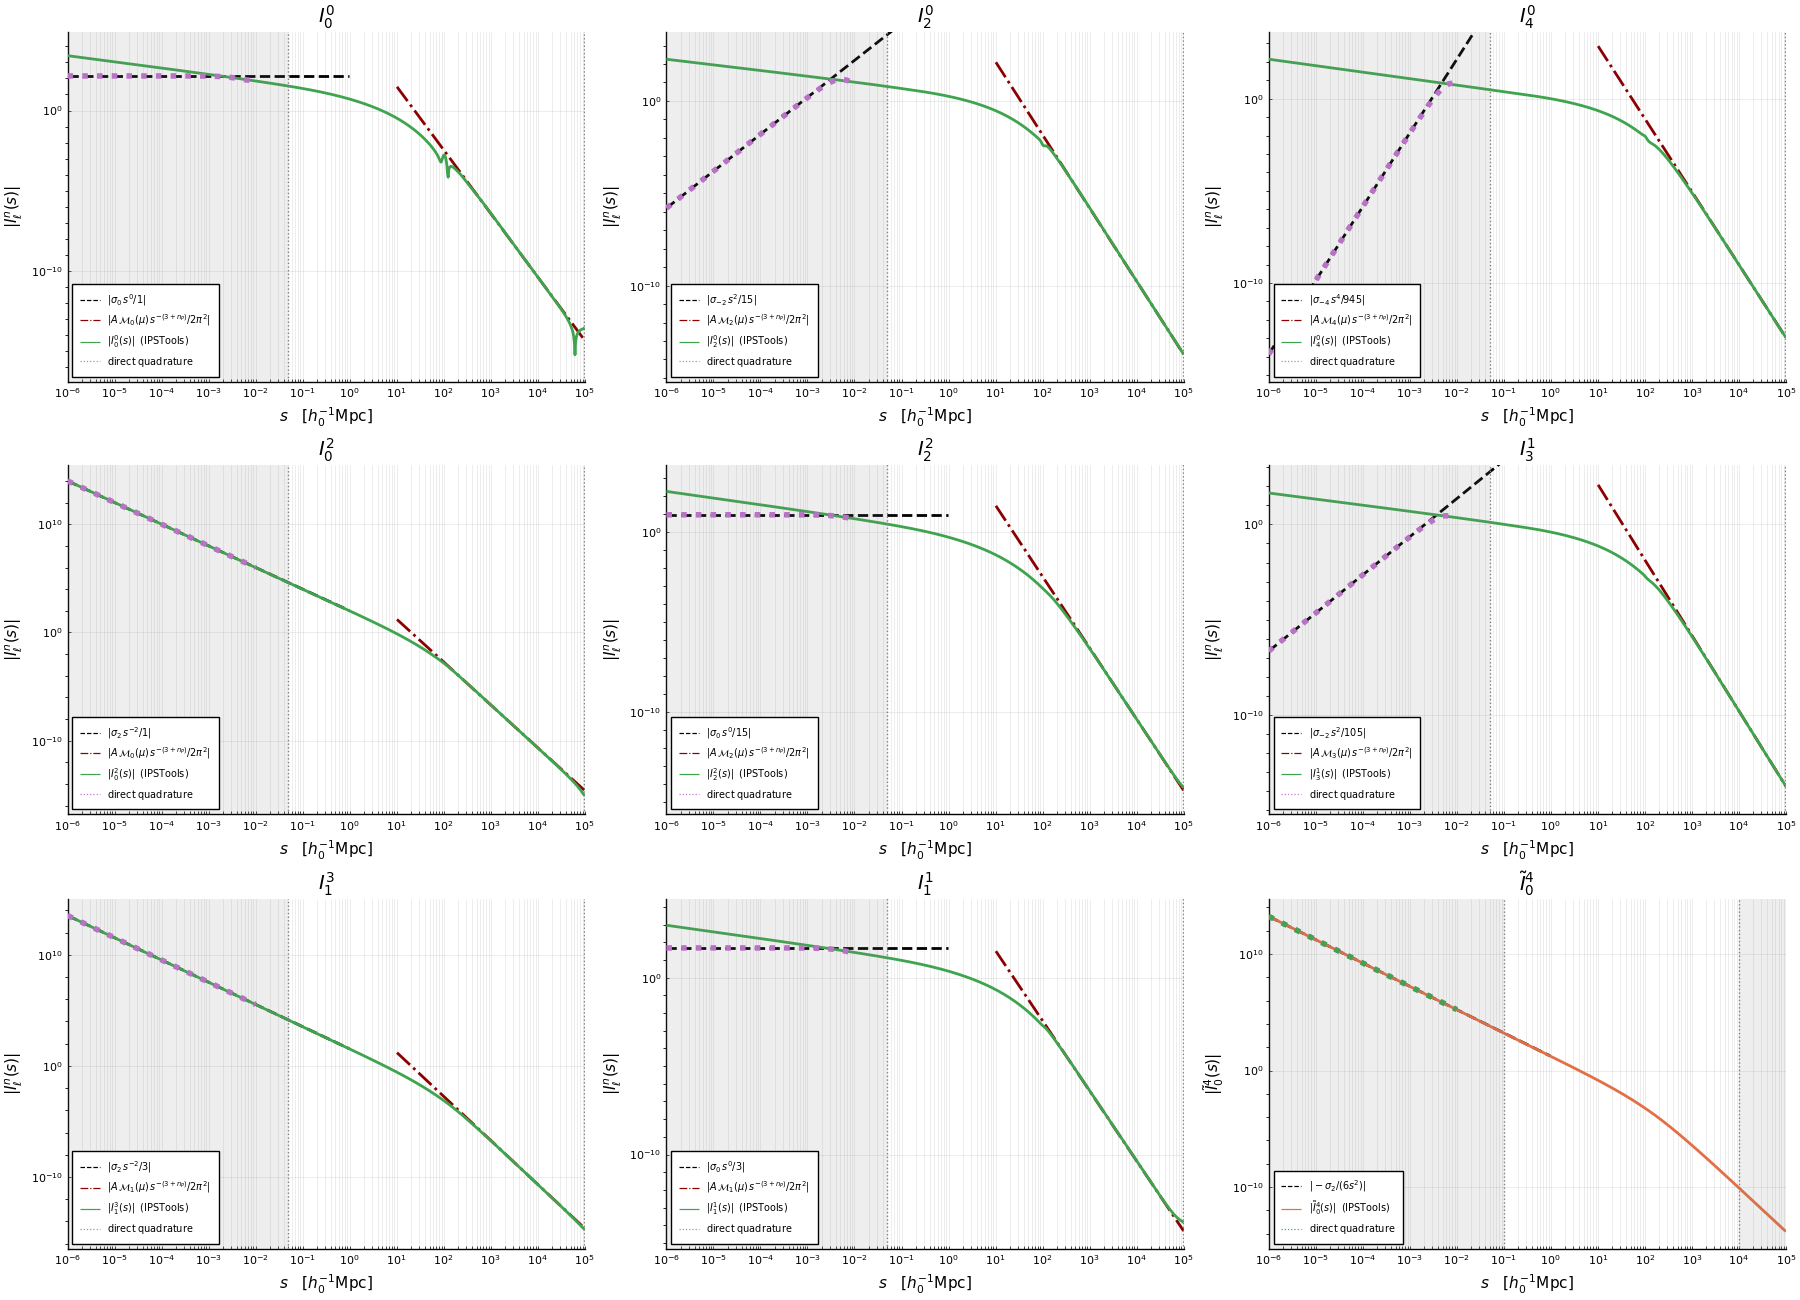

In [9]:
ps = [plot_single(name, l, n, f) for (name, l, n, f) in ILN]
push!(ps, plot_single("I04_tilde", 0, 4, tools.I04_tilde; tilde=true))
plot(ps..., layout=(3, 3), size=(1800, 1300))

And now all of them in a single figure, restricted to the region where they are
genuine splines. The three regimes are immediately visible: the curves that flatten out
($\ell = n$), the ones that go down as a power law ($\ell > n$) and the ones that blow up
($\ell < n$).

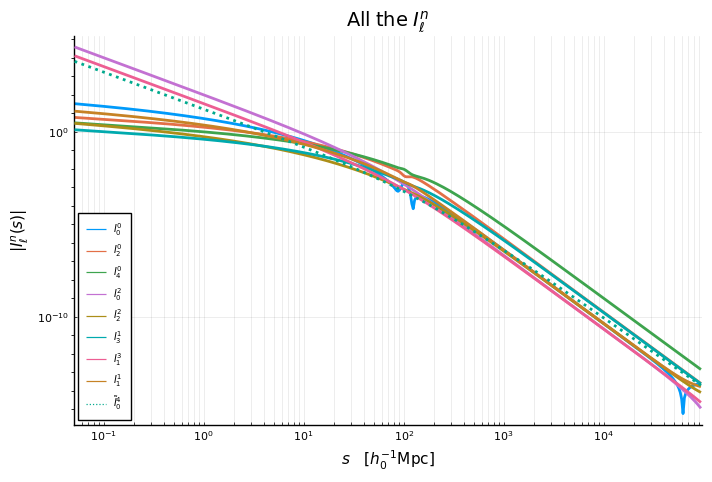

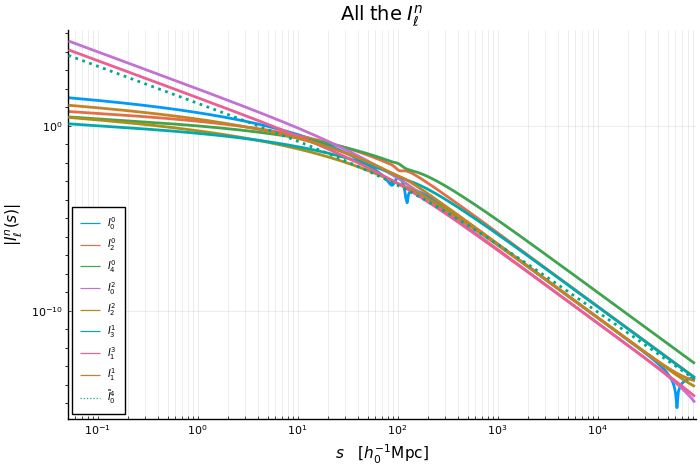

In [10]:
"""
    plot_all()

Plot all the ``|I_\\ell^n(s)|`` together in a single log-log figure, and save it as
`Iln_terms/all_Iln.png`.

Only the region where the `IntegralIPS` are splines is shown, i.e.
``[\\mathrm{left}, \\mathrm{right}]``: outside it they are power-law extrapolations,
and plotting them there would be misleading.
"""
function plot_all()
    left = maximum(f.left for (_, _, _, f) in ILN)
    right = minimum(f.right for (_, _, _, f) in ILN)
    ss = SS[left .<= SS .<= right]

    p = plot(; ylabel=L"|I_{\ell}^{n}(s)|", title=L"\mathrm{All \; the} \; I_{\ell}^{n}",
        plot_kwargs(left, right)...)
    for (name, l, n, f) in ILN
        plot!(p, ss, abs.([f(s) for s in ss]); label=L"I_{%$l}^{%$n}", lw=2)
    end
    plot!(p, ss, abs.([tools.I04_tilde(s) for s in ss]);
        label=L"\tilde{I}_0^4", lw=2, ls=:dot)

    savefig(p, joinpath(DIR, "all_Iln.png"))
    SAVE_TO_DOCS && savefig(p, joinpath(DOCS_ASSETS, "all_Iln.png"))
    return p
end

plot_all()

Finally, the actual numerical check of the limits: the ratio between the directly
computed $I_\ell^n$ and its asymptote. Every curve must tend to 1 for $s \rightarrow 0$,
and it does, to four digits below $10^{-4}$.

The three curves that sit at 1 over the whole range are $I_0^2$, $I_1^3$ and
$\tilde{I}_0^4$: their limits depend on $\sigma_2$ alone, whose integrand $P(q)$ is
weighted so that only $q \ll 1/s$ contributes, and the expansion is never actually
stressed. All the others peel off from 1 exactly where $s$ approaches
$1/k_\mathrm{max}$.

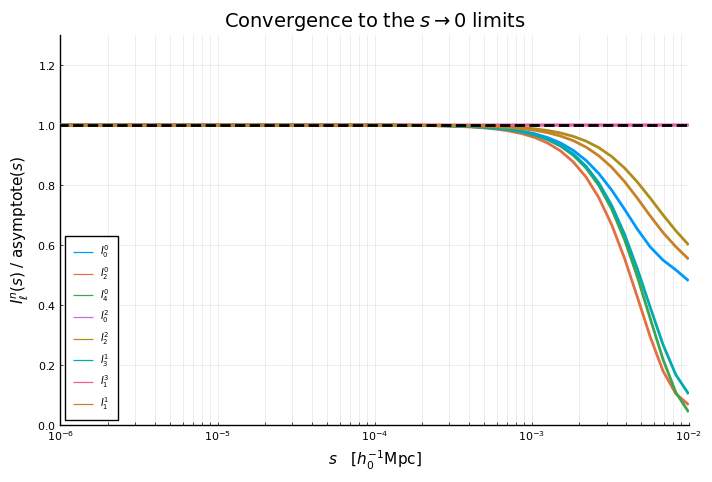

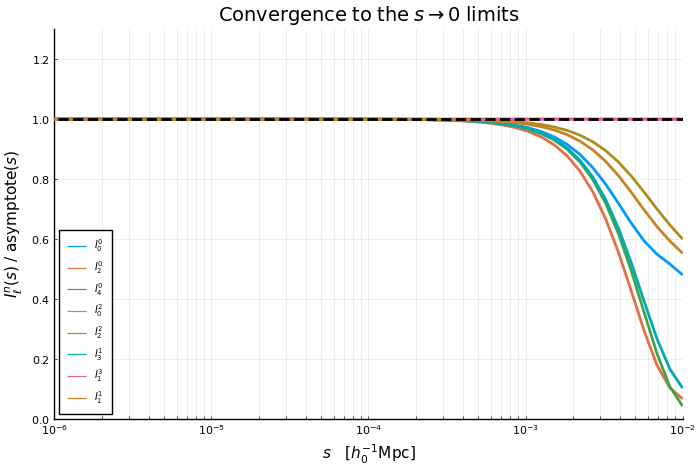

In [11]:
"""
    plot_ratios()

Plot, for each ``I_\\ell^n``, the ratio between the directly-computed integral and its
analytic small-``s`` asymptote, and save it as `Iln_terms/ratios.png`.

Every curve must tend to 1 for ``s \\rightarrow 0``: this is the actual numerical check
of the limits derived in the manual. The convergence sets in only for
``s \\lesssim 1/k_\\mathrm{max} = 10^{-3} \\, h_0^{-1}\\mathrm{Mpc}``.
"""
function plot_ratios()
    p = plot(; xaxis=:log, yaxis=:identity, ylims=(0, 1.3),
        xlabel=L"s \quad [h_0^{-1}\mathrm{Mpc}]",
        ylabel=L"I_{\ell}^{n}(s) \; / \; \mathrm{asymptote}(s)",
        title=L"\mathrm{Convergence \; to \; the} \; s \rightarrow 0 \; \mathrm{limits}",
        xticks=logticks(SS_DIRECT[begin], SS_DIRECT[end]),
        xlims=(SS_DIRECT[begin], SS_DIRECT[end]),
        legend=:bottomleft, legendfontsize=7, size=(700, 470))
    for (name, l, n, f) in ILN
        plot!(p, SS_DIRECT, [I_direct(l, n, s) / asymptote(s, l, n) for s in SS_DIRECT];
            label=L"I_{%$l}^{%$n}", lw=2)
    end
    hline!(p, [1.0]; color=:black, ls=:dash, lw=2, label="")

    savefig(p, joinpath(DIR, "ratios.png"))
    SAVE_TO_DOCS && savefig(p, joinpath(DOCS_ASSETS, "ratios.png"))
    return p
end

plot_ratios()

## The opposite end: $s \rightarrow +\infty$

Only one property of $P$ enters: its small-$k$ slope,
$P(q) \sim A \, q^{\,n_P}$ for $q \rightarrow 0^{+}$.

**Careful with $n_P$.** It is the slope of the late-time **matter** Power Spectrum, in
$(h^{-1}\mathrm{Mpc})^3$ — *not* the $n_s - 1$ of the dimensionless primordial curvature
spectrum $\Delta^2_\mathcal{R}(k) = A_s (k/k^*)^{n_s-1}$. The two are related by
$P_m(k) \propto k^4 T^2(k) P_\mathcal{R}(k) \propto k^{\,n_s} T^2(k)$, and $T \rightarrow 1$
on large scales, so $n_P = n_s \simeq 0.96$: the matter $P(k)$ *grows* at small $k$. The
cell above measures it rather than assuming it.

**The naive route does not work.** Substituting $x = qs$,

$$
    I_\ell^n(s) = \frac{s^{-3-n}}{2\pi^2} \int_0^{+\infty} \mathrm{d}x \; x^{2-n} \,
        P\!\left(\frac{x}{s}\right) j_\ell(x) \; ,
$$

one is tempted to replace $P(x/s)$ by $A(x/s)^{n_P}$ because $x/s \rightarrow 0$. But the
integral runs to $x = +\infty$, so $x/s$ is an indeterminate $\infty/\infty$: there is no
dominating function, and the resulting $\int_0^\infty x^{\mu-1} j_\ell(x)\,\mathrm{d}x$,
$\mu := 3 + n_P - n$, **diverges** whenever $\mu \geq 2$ — which is five of our eight cases.

**The proof.** Write $I_\ell^n(s) = s^{-n}\int_0^\infty f(q) j_\ell(qs)\,\mathrm{d}q$ with
$f(q) = q^{2-n}P(q)/2\pi^2$, and go to Mellin space:

$$
    I_\ell^n(s) = \frac{s^{-n}}{2\pi i}\int_{c-i\infty}^{c+i\infty} \mathrm{d}z \;
        \mathcal{M}_\ell(z) \, \tilde{f}(1-z) \, s^{-z} \; ,
    \qquad
    \mathcal{M}_\ell(z) = \sqrt{\frac{\pi}{2}} \, 2^{\,z-3/2}
        \frac{\Gamma\!\left(\frac{\ell+z}{2}\right)}{\Gamma\!\left(\frac{\ell-z+3}{2}\right)} \; .
$$

This is exact. $\mathcal{M}_\ell$ is analytic for $\mathrm{Re}\,z > -\ell$, while
$\tilde f(1-z)$ has its rightmost pole at $z = \mu$, simple, with residue $-A/2\pi^2$,
coming from the small-$q$ power law. Pushing the contour right past it,

$$
    I_\ell^n(s) \; \underset{s \rightarrow +\infty}{\sim} \;
    \frac{A}{2\pi^2} \, \mathcal{M}_\ell(3 + n_P - n) \; s^{-(3+n_P)} \; .
$$

**The exponent depends on neither $\ell$ nor $n$**: the $s^{-n}$ pulled out by the
$(qs)^{-n}$ factor exactly compensates the $n$ it subtracts from $\mu$. Only the amplitude
does. And $\mathcal{M}_\ell(\mu)$ for $\mu \geq 2$ is no fudge — the residue theorem
evaluates a function that is analytic there, it never forms the divergent integral.

No `I_direct` is needed here: the whole relevant range lies inside
$[\mathrm{left}, \mathrm{right}]$, so the `IntegralIPS` *is* the integral.
$\tilde{I}_0^4$ is left out, since its $\mu = n_P - 1 \simeq -0.04$ sits on the pole of
$\mathcal{M}_0$ at $z=0$ — see the manual.

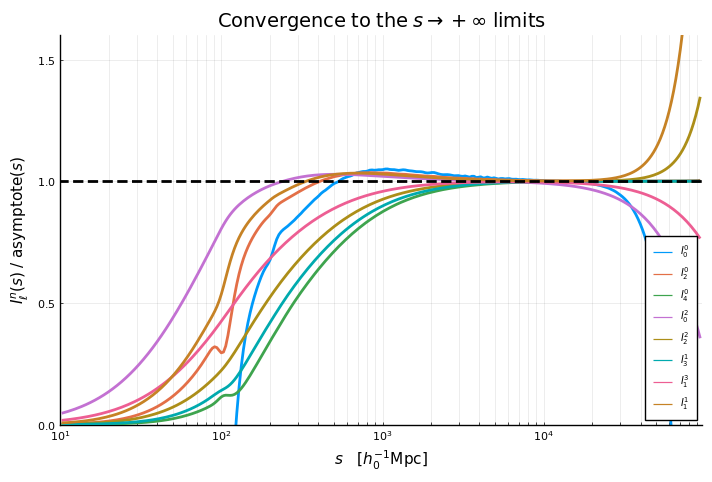

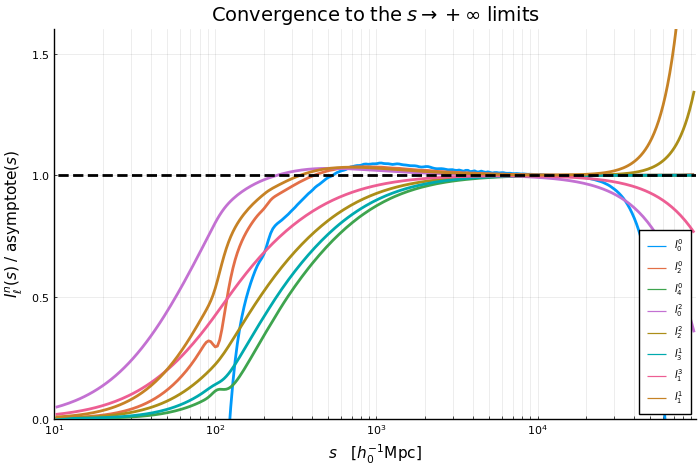

In [12]:
"""
    plot_ratios_large_s()

Plot, for each ``I_\\ell^n``, the ratio between the `IntegralIPS` stored in `IPSTools` and
its analytic large-``s`` asymptote, and save it as `Iln_terms/ratios_large_s.png`.

Every curve must tend to 1, and it does to better than 1% around
``s \\simeq 10^4 \\, h_0^{-1}\\mathrm{Mpc}``. Here there is no need for `I_direct`: the
whole range shown lies inside ``[\\mathrm{left}, \\mathrm{right}]``, so the `IntegralIPS`
IS the integral.

``\\tilde{I}_0^4`` is left out on purpose: its ``\\mu = n_P - 1 \\simeq -0.04`` sits on the
pole of ``\\Gamma(\\mu/2)``, which is precisely the ``\\sigma_4 / s^4`` divergence its
subtraction removes, so its two leading powers, ``s^{-(3+n_P)}`` and ``s^{-4}``, are
degenerate up to ``1 - n_P = 0.04`` and it never reaches a clean power law inside its own
validity window.
"""
function plot_ratios_large_s()
    lo, hi = 10.0, minimum(f.right for (_, _, _, f) in ILN)
    ss = SS[lo.<=SS.<=hi]

    p = plot(; xaxis=:log, yaxis=:identity, ylims=(0, 1.6),
        xlabel=L"s \quad [h_0^{-1}\mathrm{Mpc}]",
        ylabel=L"I_{\ell}^{n}(s) \; / \; \mathrm{asymptote}(s)",
        title=L"\mathrm{Convergence \; to \; the} \; s \rightarrow +\infty \; \mathrm{limits}",
        xticks=logticks(lo, hi), xlims=(lo, hi),
        legend=:bottomright, legendfontsize=7, size=(700, 470))
    for (name, l, n, f) in ILN
        plot!(p, ss, [f(s) / asymptote_large(s, l, n) for s in ss];
            label=L"I_{%$l}^{%$n}", lw=2)
    end
    hline!(p, [1.0]; color=:black, ls=:dash, lw=2, label="")

    savefig(p, joinpath(DIR, "ratios_large_s.png"))
    SAVE_TO_DOCS && savefig(p, joinpath(DOCS_ASSETS, "ratios_large_s.png"))
    return p
end

plot_ratios_large_s()

Finally we save the numerical values, so that the figures can be re-made without recomputing the `IPSTools`.

In [13]:
println(save_data())
println(save_direct_data())
println(save_large_s_data())

LoadError: UndefVarError: `save_data` not defined in `Main`
Suggestion: check for spelling errors or missing imports.